In [8]:
# ============================================================
# 03_modeling.ipynb — Modélisation
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, roc_curve, precision_recall_curve
)
import xgboost as xgb
import os

os.makedirs('../figures', exist_ok=True)

# Chargement
df = pd.read_parquet('../data/features_all.parquet')
print(f"✓ Dataset chargé : {df.shape[0]:,} séjours × {df.shape[1]} colonnes")
print(f"\nTargets :")
for t in ['readmit_7d','readmit_14d','readmit_30d']:
    n = df[t].sum()
    print(f"  {t} : {n:,} positifs ({n/len(df)*100:.1f}%)")

✓ Dataset chargé : 59,260 séjours × 102 colonnes

Targets :
  readmit_7d : 3,144 positifs (5.3%)
  readmit_14d : 3,709 positifs (6.3%)
  readmit_30d : 3,922 positifs (6.6%)


In [9]:
# ============================================================
# PRÉPARATION — Définition X, y, groups
# ============================================================

# Colonnes à exclure du feature set
EXCLUDE = [
    # Identifiants
    'stay_id', 'subject_id', 'hadm_id',
    # Cibles (on garde readmit_7d comme target principale)
    'readmit_7d', 'readmit_14d', 'readmit_30d',
    # Catégoriel texte — déjà encodé dans careunit_encoded
    'first_careunit', 'anchor_year_group',
    # los_hours est redondant avec los_days
    'los_hours',
]

# Features
feature_cols = [c for c in df.columns if c not in EXCLUDE]

X = df[feature_cols].copy()
y = df['readmit_7d'].copy()
groups = df['subject_id'].values  # pour StratifiedGroupKFold

print(f"✓ X : {X.shape[0]:,} × {X.shape[1]} features")
print(f"✓ y : {y.sum():,} positifs ({y.mean()*100:.1f}%)")
print(f"✓ groups : {len(np.unique(groups)):,} patients uniques")

print(f"\nFeatures ({len(feature_cols)}) :")
print(feature_cols)

# Ratio déséquilibre pour scale_pos_weight
ratio = (y == 0).sum() / (y == 1).sum()
print(f"\nscale_pos_weight = {ratio:.1f}")

✓ X : 59,260 × 93 features
✓ y : 3,144 positifs (5.3%)
✓ groups : 47,467 patients uniques

Features (93) :
['age', 'from_ed', 'los_days', 'careunit_encoded', 'hospital_los_days', 'hr_last', 'hr_max', 'hr_min', 'hr_count', 'rr_last', 'rr_max', 'rr_min', 'sbp_last', 'sbp_max', 'sbp_min', 'dbp_last', 'dbp_max', 'dbp_min', 'map_last', 'map_max', 'map_min', 'spo2_last', 'spo2_min', 'temp_last', 'temp_max', 'temp_min', 'gcs_last', 'gcs_min', 'creatinine_last', 'creatinine_max', 'bun_last', 'bun_max', 'sodium_last', 'sodium_max', 'sodium_min', 'potassium_last', 'potassium_max', 'potassium_min', 'bicarbonate_last', 'bicarbonate_min', 'chloride_last', 'hemoglobin_last', 'hemoglobin_min', 'platelets_last', 'platelets_min', 'wbc_last', 'wbc_max', 'inr_last', 'inr_max', 'lactate_last', 'lactate_max', 'albumin_last', 'bilirubin_last', 'bilirubin_max', 'alt_last', 'alt_max', 'ast_last', 'ast_max', 'ck_last', 'ck_max', 'lipase_last', 'lipase_max', 'has_lactate', 'has_albumin', 'has_bilirubin', 'has_a

In [10]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='mimic-iv-project-490314')

df = pd.read_parquet('../data/features_all.parquet')
stay_ids = df['stay_id'].tolist()

EXCLUDE = [
    'stay_id', 'subject_id', 'hadm_id',
    'readmit_7d', 'readmit_14d', 'readmit_30d',
    'first_careunit', 'anchor_year_group',
    'los_hours',
]
feature_cols = [c for c in df.columns if c not in EXCLUDE]
X = df[feature_cols].copy()
y = df['readmit_7d'].copy()
groups = df['subject_id'].values

print(f"✓ {len(df):,} séjours | {len(feature_cols)} features")
print(f"✓ {len(stay_ids):,} stay_ids prêts")

✓ 59,260 séjours | 93 features
✓ 59,260 stay_ids prêts


In [11]:
# ============================================================
# SWIFT SCORE CORRIGÉ — avec GCS total recalculé
# ============================================================

# D'abord récupérer le vrai GCS total depuis chartevents
from google.cloud import bigquery

query_gcs = """
WITH cohort AS (
    SELECT i.stay_id, i.intime, i.outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

gcs_components AS (
    SELECT
        c.stay_id,
        ce.charttime,
        SUM(CASE WHEN ce.itemid = 220739 THEN ce.valuenum ELSE 0 END) AS eye,
        SUM(CASE WHEN ce.itemid = 223900 THEN ce.valuenum ELSE 0 END) AS verbal,
        SUM(CASE WHEN ce.itemid = 223901 THEN ce.valuenum ELSE 0 END) AS motor
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce
        ON  ce.stay_id   = c.stay_id
        AND ce.charttime BETWEEN c.intime AND c.outtime
        AND ce.valuenum  IS NOT NULL
        AND ce.itemid IN (220739, 223900, 223901)
    GROUP BY c.stay_id, ce.charttime
),

gcs_total AS (
    SELECT
        stay_id,
        charttime,
        eye + verbal + motor AS gcs_total
    FROM gcs_components
    WHERE eye > 0 AND verbal > 0 AND motor > 0
),

gcs_last AS (
    SELECT stay_id, gcs_total AS gcs_total_last
    FROM (
        SELECT *,
            ROW_NUMBER() OVER (
                PARTITION BY stay_id ORDER BY charttime DESC
            ) AS rn
        FROM gcs_total
    )
    WHERE rn = 1
)

SELECT
    c.stay_id,
    g.gcs_total_last
FROM (SELECT DISTINCT stay_id FROM `physionet-data.mimiciv_3_1_icu.icustays`
      WHERE stay_id IN UNNEST(@stay_ids)) c
LEFT JOIN gcs_last g ON g.stay_id = c.stay_id
"""

print("Récupération GCS total (2-3 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_gcs = client.query(query_gcs, job_config=job_config).to_dataframe()

print(f"✓ {len(df_gcs):,} séjours")
print(f"  GCS total coverage : {df_gcs['gcs_total_last'].notna().mean()*100:.1f}%")
print(f"  GCS total median   : {df_gcs['gcs_total_last'].median():.0f}")
print(f"  GCS total min      : {df_gcs['gcs_total_last'].min():.0f}")
print(f"  GCS total max      : {df_gcs['gcs_total_last'].max():.0f}")

Récupération GCS total (2-3 min)...
✓ 59,260 séjours
  GCS total coverage : 100.0%
  GCS total median   : 15
  GCS total min      : 3
  GCS total max      : 15


In [12]:
# ============================================================
# SWIFT SCORE CORRIGÉ — GCS total
# ============================================================

# Fusion GCS total dans df
df_swift = df.merge(df_gcs, on='stay_id', how='left')

def compute_swift(row):
    score = 0

    # 1. Source admission
    score += 0 if row['from_ed'] == 1 else 8

    # 2. LOS ICU
    los = row['los_days']
    score += 14 if los > 10 else 1 if los >= 2 else 0

    # 3. PaO2/FiO2 — si manquant : normal (Gajic)
    pf = row['pf_ratio_last'] if pd.notna(row['pf_ratio_last']) else 400
    score += 13 if pf < 100 else 10 if pf < 150 else 5 if pf < 400 else 0

    # 4. GCS total à la sortie — si manquant : 15 (normal)
    gcs = row['gcs_total_last'] if pd.notna(row['gcs_total_last']) else 15
    score += 24 if gcs < 8 else 14 if gcs < 11 else 6 if gcs < 14 else 0

    # 5. PaCO2 — si manquant : normal (≤ 45)
    paco2 = row['paco2_last'] if pd.notna(row['paco2_last']) else 40
    score += 5 if paco2 > 45 else 0

    return score

print("Calcul SWIFT score...")
df_swift['swift_score'] = df_swift.apply(compute_swift, axis=1)
df_swift['swift_positive'] = (df_swift['swift_score'] >= 15).astype(int)

# Métriques
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

y_swift = df_swift['readmit_7d']
auroc = roc_auc_score(y_swift, df_swift['swift_score'])
prauc = average_precision_score(y_swift, df_swift['swift_score'])
# Normalisation 0-1 pour Brier
swift_norm = df_swift['swift_score'] / 64
brier = brier_score_loss(y_swift, swift_norm)

print("\n=== BASELINE — SWIFT Score (corrigé) ===")
print(f"  AUROC      : {auroc:.4f}")
print(f"  PR-AUC     : {prauc:.4f}")
print(f"  Brier      : {brier:.4f}")
print(f"\n  Score moyen  : {df_swift['swift_score'].mean():.1f} ± "
      f"{df_swift['swift_score'].std():.1f}")
print(f"  Score médian : {df_swift['swift_score'].median():.0f}")
print(f"\n  Prévalence SWIFT+ (≥15) : "
      f"{df_swift['swift_positive'].mean()*100:.1f}%")
print(f"  Réadmission parmi SWIFT+ : "
      f"{y_swift[df_swift['swift_positive']==1].mean()*100:.1f}%")
print(f"  Réadmission parmi SWIFT- : "
      f"{y_swift[df_swift['swift_positive']==0].mean()*100:.1f}%")
print(f"\n  Référence littérature : AUROC 0.51–0.58 sur MIMIC-IV")

# Sauvegarde du score pour comparaison finale
df[['stay_id']].assign(swift_score=df_swift['swift_score'].values,
                       swift_norm=swift_norm.values).to_parquet(
    '../data/swift_scores.parquet', index=False)

Calcul SWIFT score...

=== BASELINE — SWIFT Score (corrigé) ===
  AUROC      : 0.5303
  PR-AUC     : 0.0598
  Brier      : 0.0720

  Score moyen  : 9.4 ± 7.7
  Score médian : 9

  Prévalence SWIFT+ (≥15) : 14.4%
  Réadmission parmi SWIFT+ : 7.1%
  Réadmission parmi SWIFT- : 5.0%

  Référence littérature : AUROC 0.51–0.58 sur MIMIC-IV


In [13]:
# Résumé baseline à garder en mémoire
SWIFT_AUROC = 0.5303
SWIFT_PRAUC = 0.0598
SWIFT_BRIER = 0.0720
print(f"✓ Baseline SWIFT enregistrée : AUROC={SWIFT_AUROC}")

✓ Baseline SWIFT enregistrée : AUROC=0.5303


In [14]:
# ============================================================
# CORRECTION — Ajout gcs_total + features composites
# ============================================================

# 1. Ajouter gcs_total_last depuis df_gcs
df_gcs.to_parquet('../data/features_gcs_total.parquet', index=False)

# Fusionner dans X
X['gcs_total_last'] = df_gcs.set_index('stay_id').loc[
    df['stay_id'], 'gcs_total_last'
].values

# 2. BUN / Créatinine ratio
X['bun_creatinine_ratio'] = X['bun_last'] / X['creatinine_last'].replace(0, np.nan)

# 3. Vérification
print("Features ajoutées :")
print(f"  gcs_total_last  : {X['gcs_total_last'].notna().mean()*100:.1f}% coverage")
print(f"    median = {X['gcs_total_last'].median():.0f} (attendu 15)")
print(f"  bun_creatinine_ratio : {X['bun_creatinine_ratio'].notna().mean()*100:.1f}% coverage")
print(f"    median = {X['bun_creatinine_ratio'].median():.1f}")
print(f"\nX shape : {X.shape}")

Features ajoutées :
  gcs_total_last  : 100.0% coverage
    median = 15 (attendu 15)
  bun_creatinine_ratio : 99.5% coverage
    median = 19.1

X shape : (59260, 95)


In [15]:
# ============================================================
# CORRECTION IMMÉDIATE
# 1. Supprimer gcs_last et gcs_min (Eye Opening incorrect)
# 2. Vérifier l'impact
# ============================================================

print("Suppression gcs_last et gcs_min (Eye Opening, pas GCS total)...")
X = X.drop(columns=['gcs_last', 'gcs_min'], errors='ignore')
print(f"X shape après suppression : {X.shape}")

# Vérification gcs_total_last remplace bien
print(f"\ngcs_total_last : median={X['gcs_total_last'].median():.0f} | "
      f"coverage={X['gcs_total_last'].notna().mean()*100:.1f}%")

# Nouvelle corrélation GCS
corr_gcs = X['gcs_total_last'].fillna(15).corr(y, method='spearman')
print(f"Corrélation gcs_total_last vs readmit_7d : {abs(corr_gcs):.4f}")

# Mise à jour feature_cols
feature_cols = list(X.columns)
print(f"\nFeatures finales : {len(feature_cols)}")

Suppression gcs_last et gcs_min (Eye Opening, pas GCS total)...
X shape après suppression : (59260, 93)

gcs_total_last : median=15 | coverage=100.0%
Corrélation gcs_total_last vs readmit_7d : 0.0332

Features finales : 93


In [16]:
# ============================================================
# XGBOOST v3 — gcs corrigé, features finales
# ============================================================

results_xgb3 = []
oof_proba3   = np.zeros(len(X))

print("XGBoost v3 — gcs_total corrigé")
print("="*45)

for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(X, y, groups=groups)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp   = imputer.transform(X_val)

    p1  = np.nanpercentile(X_train_imp, 1,  axis=0)
    p99 = np.nanpercentile(X_train_imp, 99, axis=0)
    X_train_imp = np.clip(X_train_imp, p1, p99)
    X_val_imp   = np.clip(X_val_imp,   p1, p99)

    model = xgb.XGBClassifier(
        n_estimators          = 500,
        learning_rate         = 0.05,
        max_depth             = 6,
        scale_pos_weight      = 17.8,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 10,
        reg_alpha             = 0.1,
        reg_lambda            = 1.0,
        eval_metric           = 'aucpr',
        early_stopping_rounds = 30,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0,
    )
    model.fit(
        X_train_imp, y_train,
        eval_set=[(X_val_imp, y_val)],
        verbose=False,
    )

    y_proba = model.predict_proba(X_val_imp)[:, 1]
    oof_proba3[val_idx] = y_proba

    auroc = roc_auc_score(y_val, y_proba)
    prauc = average_precision_score(y_val, y_proba)
    brier = brier_score_loss(y_val, y_proba)

    results_xgb3.append({'fold': fold+1,
                          'auroc': auroc,
                          'prauc': prauc,
                          'brier': brier})

    print(f"  Fold {fold+1} | AUROC={auroc:.4f} | "
          f"PR-AUC={prauc:.4f} | Brier={brier:.4f}")

df_res3    = pd.DataFrame(results_xgb3)
oof_auroc3 = roc_auc_score(y, oof_proba3)

print(f"\n{'='*45}")
print(f"  AUROC  : {df_res3['auroc'].mean():.4f} ± {df_res3['auroc'].std():.4f}")
print(f"  PR-AUC : {df_res3['prauc'].mean():.4f} ± {df_res3['prauc'].std():.4f}")
print(f"  Brier  : {df_res3['brier'].mean():.4f} ± {df_res3['brier'].std():.4f}")
print(f"\n  OOF AUROC global  : {oof_auroc3:.4f}")
print(f"  vs SWIFT baseline : {oof_auroc3 - SWIFT_AUROC:+.4f}")
print(f"\n  Contexte littérature :")
print(f"  SWIFT sur MIMIC-IV     : 0.51–0.58")
print(f"  Neves 2024 (MIMIC-IV)  : 0.68–0.70")
print(f"  Shi 2022 (ext. MIMIC)  : 0.60")

np.save('../data/oof_xgb3.npy', oof_proba3)

XGBoost v3 — gcs_total corrigé


NameError: name 'sgkf' is not defined

In [17]:
# ============================================================
# INIT — Rechargement complet
# ============================================================
from google.cloud import bigquery
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Données
df       = pd.read_parquet('../data/features_all.parquet')
df_gcs   = pd.read_parquet('../data/features_gcs_total.parquet')

EXCLUDE = ['stay_id','subject_id','hadm_id','readmit_7d','readmit_14d',
           'readmit_30d','first_careunit','anchor_year_group','los_hours',
           'gcs_last','gcs_min']  # Eye Opening incorrect

feature_cols = [c for c in df.columns if c not in EXCLUDE]
X = df[feature_cols].copy()

# Ajout features corrigées/composites
X['gcs_total_last']     = df_gcs.set_index('stay_id').loc[df['stay_id'], 'gcs_total_last'].values
X['bun_creatinine_ratio'] = X['bun_last'] / X['creatinine_last'].replace(0, np.nan)

y      = df['readmit_7d'].copy()
groups = df['subject_id'].values
stay_ids = df['stay_id'].tolist()

SWIFT_AUROC = 0.5303
SWIFT_PRAUC = 0.0598
SWIFT_BRIER = 0.0720

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Recharge OOF XGBoost v3
oof_proba3  = np.load('../data/oof_xgb3.npy')
df_res3 = pd.DataFrame({
    'fold':  [1,2,3,4,5],
    'auroc': [0.6647, 0.6497, 0.6636, 0.6569, 0.6775],
    'prauc': [0.1171, 0.0957, 0.1104, 0.1091, 0.1268],
    'brier': [0.1730, 0.1880, 0.1827, 0.1644, 0.1655],
})

print(f"✓ X : {X.shape[0]:,} × {X.shape[1]} features")
print(f"✓ y : {y.sum():,} positifs ({y.mean()*100:.1f}%)")
print(f"✓ XGBoost OOF AUROC : {roc_auc_score(y, oof_proba3):.4f}")

✓ X : 59,260 × 93 features
✓ y : 3,144 positifs (5.3%)
✓ XGBoost OOF AUROC : 0.6619


In [18]:
# ============================================================
# TOUS LES MODÈLES — LightGBM, Random Forest, LR-L1
# ============================================================
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

all_results = {'XGBoost': {'scores': df_res3, 'oof': oof_proba3}}

# ── Configs modèles ───────────────────────────────────────
models_config = {
    'LightGBM': lgb.LGBMClassifier(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 6,
        scale_pos_weight  = 17.8,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_samples = 20,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        random_state      = 42,
        n_jobs            = -1,
        verbosity         = -1,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators     = 300,
        max_depth        = 10,
        class_weight     = 'balanced',
        min_samples_leaf = 20,
        max_features     = 'sqrt',
        random_state     = 42,
        n_jobs           = -1,
    ),
    'LogisticRegression': LogisticRegression(
        penalty      = 'l1',
        solver       = 'saga',
        C            = 0.1,
        class_weight = 'balanced',
        max_iter     = 500,
        random_state = 42,
        n_jobs       = -1, 
    ),
}

# ── Boucle sur les modèles ────────────────────────────────
for model_name, model in models_config.items():
    print(f"\n{'='*45}")
    print(f"{model_name}")
    print(f"{'='*45}")

    fold_results = []
    oof_p = np.zeros(len(X))

    for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(X, y, groups=groups)):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Imputation
        imputer = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_train)
        X_val_imp   = imputer.transform(X_val)

        # Winsorisation (surtout utile pour LR)
        p1  = np.nanpercentile(X_train_imp, 1,  axis=0)
        p99 = np.nanpercentile(X_train_imp, 99, axis=0)
        X_train_imp = np.clip(X_train_imp, p1, p99)
        X_val_imp   = np.clip(X_val_imp,   p1, p99)

        # Fit
        if model_name == 'LightGBM':
            model.fit(
                X_train_imp, y_train,
                eval_set=[(X_val_imp, y_val)],
                callbacks=[lgb.early_stopping(30, verbose=False),
                           lgb.log_evaluation(-1)]
            )
        else:
            model.fit(X_train_imp, y_train)

        y_proba = model.predict_proba(X_val_imp)[:, 1]
        oof_p[val_idx] = y_proba

        auroc = roc_auc_score(y_val, y_proba)
        prauc = average_precision_score(y_val, y_proba)
        brier = brier_score_loss(y_val, y_proba)
        fold_results.append({'fold': fold+1,
                             'auroc': auroc,
                             'prauc': prauc,
                             'brier': brier})

        print(f"  Fold {fold+1} | AUROC={auroc:.4f} | "
              f"PR-AUC={prauc:.4f} | Brier={brier:.4f}")

    df_fold = pd.DataFrame(fold_results)
    all_results[model_name] = {'scores': df_fold, 'oof': oof_p}

    print(f"\n  AUROC  : {df_fold['auroc'].mean():.4f} ± "
          f"{df_fold['auroc'].std():.4f}")
    print(f"  PR-AUC : {df_fold['prauc'].mean():.4f} ± "
          f"{df_fold['prauc'].std():.4f}")
    print(f"  Brier  : {df_fold['brier'].mean():.4f} ± "
          f"{df_fold['brier'].std():.4f}")
    print(f"  OOF AUROC : {roc_auc_score(y, oof_p):.4f}")

# ── Tableau comparatif final ──────────────────────────────
print(f"\n{'='*55}")
print(f"{'MODÈLE':<22} {'AUROC':>8} {'±':>6} {'PR-AUC':>8} {'Brier':>8}")
print(f"{'─'*55}")
print(f"{'SWIFT (baseline)':<22} {SWIFT_AUROC:>8.4f} {'':>6} "
      f"{0.0598:>8.4f} {0.0720:>8.4f}")

for name, res in all_results.items():
    df_r = res['scores']
    oof_auroc = roc_auc_score(y, res['oof'])
    print(f"  {name:<20} {df_r['auroc'].mean():>8.4f} "
          f"±{df_r['auroc'].std():>5.4f} "
          f"{df_r['prauc'].mean():>8.4f} "
          f"{df_r['brier'].mean():>8.4f}")
print(f"{'='*55}")


LightGBM
  Fold 1 | AUROC=0.5966 | PR-AUC=0.0766 | Brier=0.0507
  Fold 2 | AUROC=0.5616 | PR-AUC=0.0670 | Brier=0.0508
  Fold 3 | AUROC=0.5982 | PR-AUC=0.0761 | Brier=0.0506
  Fold 4 | AUROC=0.5774 | PR-AUC=0.0708 | Brier=0.0507
  Fold 5 | AUROC=0.6026 | PR-AUC=0.0809 | Brier=0.0506

  AUROC  : 0.5873 ± 0.0173
  PR-AUC : 0.0743 ± 0.0054
  Brier  : 0.0507 ± 0.0001
  OOF AUROC : 0.5883

RandomForest
  Fold 1 | AUROC=0.6438 | PR-AUC=0.0910 | Brier=0.1581
  Fold 2 | AUROC=0.6324 | PR-AUC=0.0834 | Brier=0.1551
  Fold 3 | AUROC=0.6566 | PR-AUC=0.0966 | Brier=0.1575
  Fold 4 | AUROC=0.6404 | PR-AUC=0.0893 | Brier=0.1561
  Fold 5 | AUROC=0.6626 | PR-AUC=0.0994 | Brier=0.1575

  AUROC  : 0.6471 ± 0.0122
  PR-AUC : 0.0920 ± 0.0063
  Brier  : 0.1569 ± 0.0012
  OOF AUROC : 0.6467

LogisticRegression
  Fold 1 | AUROC=0.6590 | PR-AUC=0.0957 | Brier=0.2332
  Fold 2 | AUROC=0.6183 | PR-AUC=0.0800 | Brier=0.2326
  Fold 3 | AUROC=0.6427 | PR-AUC=0.0855 | Brier=0.2320
  Fold 4 | AUROC=0.6291 | PR-AUC=0.

In [19]:
# ============================================================
# CORRECTION LightGBM + vérification tous modèles
# ============================================================

print("=== Vérification distributions OOF ===")
for name, res in all_results.items():
    oof = res['oof']
    print(f"\n{name} :")
    print(f"  mean={oof.mean():.4f} | median={np.median(oof):.4f} | "
          f"max={oof.max():.4f} | min={oof.min():.4f}")
    print(f"  % prédit > 0.1 : {(oof > 0.1).mean()*100:.1f}%")
    print(f"  % prédit > 0.3 : {(oof > 0.3).mean()*100:.1f}%")

=== Vérification distributions OOF ===

XGBoost :
  mean=0.3933 | median=0.3867 | max=0.8980 | min=0.0535
  % prédit > 0.1 : 99.8%
  % prédit > 0.3 : 74.3%

LightGBM :
  mean=0.0783 | median=0.0791 | max=0.1140 | min=0.0506
  % prédit > 0.1 : 0.1%
  % prédit > 0.3 : 0.0%

RandomForest :
  mean=0.3760 | median=0.3716 | max=0.6750 | min=0.1524
  % prédit > 0.1 : 100.0%
  % prédit > 0.3 : 80.6%

LogisticRegression :
  mean=0.4715 | median=0.4607 | max=0.9202 | min=0.1775
  % prédit > 0.1 : 100.0%
  % prédit > 0.3 : 95.8%


In [20]:
# ============================================================
# CORRECTION LightGBM — early stopping sur bonne métrique
# ============================================================

print("LightGBM corrigé")
print("="*45)

lgb_model_fixed = lgb.LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 6,
    scale_pos_weight  = 17.8,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = -1,
)

fold_results_lgb = []
oof_lgb = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(X, y, groups=groups)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp   = imputer.transform(X_val)

    p1  = np.nanpercentile(X_train_imp, 1,  axis=0)
    p99 = np.nanpercentile(X_train_imp, 99, axis=0)
    X_train_imp = np.clip(X_train_imp, p1, p99)
    X_val_imp   = np.clip(X_val_imp,   p1, p99)

    lgb_model_fixed.fit(
        X_train_imp, y_train,
        eval_set    = [(X_val_imp, y_val)],
        eval_metric = 'auc',           # ← métrique correcte
        callbacks   = [
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    y_proba = lgb_model_fixed.predict_proba(X_val_imp)[:, 1]
    oof_lgb[val_idx] = y_proba

    auroc = roc_auc_score(y_val, y_proba)
    prauc = average_precision_score(y_val, y_proba)
    brier = brier_score_loss(y_val, y_proba)
    fold_results_lgb.append({'fold': fold+1,
                              'auroc': auroc,
                              'prauc': prauc,
                              'brier': brier})

    print(f"  Fold {fold+1} | AUROC={auroc:.4f} | "
          f"PR-AUC={prauc:.4f} | Brier={brier:.4f} | "
          f"best_iter={lgb_model_fixed.best_iteration_}")

df_lgb = pd.DataFrame(fold_results_lgb)
print(f"\n{'='*45}")
print(f"  AUROC  : {df_lgb['auroc'].mean():.4f} ± {df_lgb['auroc'].std():.4f}")
print(f"  PR-AUC : {df_lgb['prauc'].mean():.4f} ± {df_lgb['prauc'].std():.4f}")
print(f"  Brier  : {df_lgb['brier'].mean():.4f} ± {df_lgb['brier'].std():.4f}")
print(f"  OOF AUROC : {roc_auc_score(y, oof_lgb):.4f}")
print(f"\n  Distribution OOF :")
print(f"  mean={oof_lgb.mean():.4f} | max={oof_lgb.max():.4f}")

LightGBM corrigé
  Fold 1 | AUROC=0.5966 | PR-AUC=0.0766 | Brier=0.0507 | best_iter=1
  Fold 2 | AUROC=0.5616 | PR-AUC=0.0670 | Brier=0.0508 | best_iter=1
  Fold 3 | AUROC=0.5982 | PR-AUC=0.0761 | Brier=0.0506 | best_iter=1
  Fold 4 | AUROC=0.5774 | PR-AUC=0.0708 | Brier=0.0507 | best_iter=1
  Fold 5 | AUROC=0.6026 | PR-AUC=0.0809 | Brier=0.0506 | best_iter=1

  AUROC  : 0.5873 ± 0.0173
  PR-AUC : 0.0743 ± 0.0054
  Brier  : 0.0507 ± 0.0001
  OOF AUROC : 0.5883

  Distribution OOF :
  mean=0.0783 | max=0.1140


In [21]:
# ============================================================
# GRID SEARCH RAPIDE — scale_pos_weight sur Fold 1 uniquement
# ============================================================

train_idx, val_idx = list(sgkf.split(X, y, groups=groups))[0]
X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)

p1  = np.nanpercentile(X_train_imp, 1,  axis=0)
p99 = np.nanpercentile(X_train_imp, 99, axis=0)
X_train_imp = np.clip(X_train_imp, p1, p99)
X_val_imp   = np.clip(X_val_imp,   p1, p99)

print("=== XGBoost — test scale_pos_weight (Fold 1) ===")
print(f"{'weight':<10} {'AUROC':>8} {'PR-AUC':>8} {'Brier':>8}")
print("─"*38)

for spw in [1, 3, 5, 10, 15, 17.8, 25, 50]:
    m = xgb.XGBClassifier(
        n_estimators          = 500,
        learning_rate         = 0.05,
        max_depth             = 6,
        scale_pos_weight      = spw,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 10,
        reg_alpha             = 0.1,
        reg_lambda            = 1.0,
        eval_metric           = 'aucpr',
        early_stopping_rounds = 30,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0,
    )
    m.fit(X_train_imp, y_train,
          eval_set=[(X_val_imp, y_val)],
          verbose=False)
    p = m.predict_proba(X_val_imp)[:, 1]
    auroc = roc_auc_score(y_val, p)
    prauc = average_precision_score(y_val, p)
    brier = brier_score_loss(y_val, p)
    print(f"{spw:<10} {auroc:>8.4f} {prauc:>8.4f} {brier:>8.4f}")

print("\n=== Random Forest — test class_weight (Fold 1) ===")
print(f"{'weight':<15} {'AUROC':>8} {'PR-AUC':>8} {'Brier':>8}")
print("─"*43)

for cw in ['balanced', 'balanced_subsample',
           {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:17.8}, {0:1, 1:25}]:
    m = RandomForestClassifier(
        n_estimators     = 300,
        max_depth        = 10,
        class_weight     = cw,
        min_samples_leaf = 20,
        max_features     = 'sqrt',
        random_state     = 42,
        n_jobs           = -1,
    )
    m.fit(X_train_imp, y_train)
    p = m.predict_proba(X_val_imp)[:, 1]
    auroc = roc_auc_score(y_val, p)
    prauc = average_precision_score(y_val, p)
    brier = brier_score_loss(y_val, p)
    label = str(cw) if isinstance(cw, dict) else cw
    print(f"{label:<15} {auroc:>8.4f} {prauc:>8.4f} {brier:>8.4f}")

=== XGBoost — test scale_pos_weight (Fold 1) ===
weight        AUROC   PR-AUC    Brier
──────────────────────────────────────
1            0.6804   0.1272   0.0487
3            0.6818   0.1315   0.0549
5            0.6746   0.1348   0.0679
10           0.6752   0.1248   0.1108
15           0.6668   0.1172   0.1545
17.8         0.6647   0.1171   0.1730
25           0.6669   0.1188   0.2298
50           0.6446   0.1016   0.3548

=== Random Forest — test class_weight (Fold 1) ===
weight             AUROC   PR-AUC    Brier
───────────────────────────────────────────
balanced          0.6438   0.0910   0.1581
balanced_subsample   0.6438   0.0921   0.1576
{0: 1, 1: 5}      0.6559   0.0958   0.0673
{0: 1, 1: 10}     0.6539   0.0950   0.1028
{0: 1, 1: 17.8}   0.6491   0.0921   0.1574
{0: 1, 1: 25}     0.6409   0.0892   0.2026


In [22]:
# ============================================================
# XGBOOST v4 — scale_pos_weight=1 (non pondéré)
# ============================================================

results_xgb4 = []
oof_proba4   = np.zeros(len(X))

print("XGBoost v4 — scale_pos_weight=1")
print("="*45)

for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(X, y, groups=groups)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp   = imputer.transform(X_val)

    p1  = np.nanpercentile(X_train_imp, 1,  axis=0)
    p99 = np.nanpercentile(X_train_imp, 99, axis=0)
    X_train_imp = np.clip(X_train_imp, p1, p99)
    X_val_imp   = np.clip(X_val_imp,   p1, p99)

    model = xgb.XGBClassifier(
        n_estimators          = 500,
        learning_rate         = 0.05,
        max_depth             = 6,
        scale_pos_weight      = 1,      # ← pas de pondération
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 10,
        reg_alpha             = 0.1,
        reg_lambda            = 1.0,
        eval_metric           = 'auc',  # ← auc au lieu de aucpr
        early_stopping_rounds = 30,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0,
    )
    model.fit(
        X_train_imp, y_train,
        eval_set=[(X_val_imp, y_val)],
        verbose=False,
    )

    y_proba = model.predict_proba(X_val_imp)[:, 1]
    oof_proba4[val_idx] = y_proba

    auroc = roc_auc_score(y_val, y_proba)
    prauc = average_precision_score(y_val, y_proba)
    brier = brier_score_loss(y_val, y_proba)

    results_xgb4.append({'fold': fold+1,
                          'auroc': auroc,
                          'prauc': prauc,
                          'brier': brier})

    print(f"  Fold {fold+1} | AUROC={auroc:.4f} | "
          f"PR-AUC={prauc:.4f} | Brier={brier:.4f}")

df_res4    = pd.DataFrame(results_xgb4)
oof_auroc4 = roc_auc_score(y, oof_proba4)

print(f"\n{'='*45}")
print(f"  AUROC  : {df_res4['auroc'].mean():.4f} ± {df_res4['auroc'].std():.4f}")
print(f"  PR-AUC : {df_res4['prauc'].mean():.4f} ± {df_res4['prauc'].std():.4f}")
print(f"  Brier  : {df_res4['brier'].mean():.4f} ± {df_res4['brier'].std():.4f}")
print(f"\n  OOF AUROC global  : {oof_auroc4:.4f}")
print(f"  vs XGBoost v3     : {oof_auroc4 - 0.6619:+.4f}")
print(f"  vs SWIFT baseline : {oof_auroc4 - SWIFT_AUROC:+.4f}")
print(f"\n  Distribution OOF :")
print(f"  mean={oof_proba4.mean():.4f} | "
      f"median={np.median(oof_proba4):.4f} | "
      f"max={oof_proba4.max():.4f}")

np.save('../data/oof_xgb4.npy', oof_proba4)

XGBoost v4 — scale_pos_weight=1
  Fold 1 | AUROC=0.6807 | PR-AUC=0.1269 | Brier=0.0487
  Fold 2 | AUROC=0.6587 | PR-AUC=0.1030 | Brier=0.0494
  Fold 3 | AUROC=0.6724 | PR-AUC=0.1067 | Brier=0.0491
  Fold 4 | AUROC=0.6675 | PR-AUC=0.1195 | Brier=0.0490
  Fold 5 | AUROC=0.6924 | PR-AUC=0.1330 | Brier=0.0486

  AUROC  : 0.6743 ± 0.0129
  PR-AUC : 0.1178 ± 0.0128
  Brier  : 0.0490 ± 0.0003

  OOF AUROC global  : 0.6735
  vs XGBoost v3     : +0.0116
  vs SWIFT baseline : +0.1432

  Distribution OOF :
  mean=0.0522 | median=0.0435 | max=0.7034


In [ ]:
# ============================================================
# XGBOOST v5 — early stopping propre (sous-split interne 10%)
# Le fold de validation reste "vierge" : non utilise pendant fit
# ============================================================

from sklearn.model_selection import train_test_split

results_xgb5 = []
oof_proba5   = np.zeros(len(X))

print('XGBoost v5 - early stopping interne (val fold vierge)')
print('='*55)

for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(X, y, groups=groups)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Imputation + winsorisation sur train fold
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp   = imputer.transform(X_val)

    p1  = np.nanpercentile(X_train_imp, 1,  axis=0)
    p99 = np.nanpercentile(X_train_imp, 99, axis=0)
    X_train_imp = np.clip(X_train_imp, p1, p99)
    X_val_imp   = np.clip(X_val_imp,   p1, p99)

    # Sous-split interne 10% pour early stopping
    # X_val reste entierement vierge (non vu pendant fit)
    X_tr, X_es, y_tr, y_es = train_test_split(
        X_train_imp, y_train,
        test_size=0.1, stratify=y_train, random_state=42
    )

    model = xgb.XGBClassifier(
        n_estimators          = 1000,
        learning_rate         = 0.05,
        max_depth             = 6,
        scale_pos_weight      = 1,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 10,
        reg_alpha             = 0.1,
        reg_lambda            = 1.0,
        eval_metric           = 'auc',
        early_stopping_rounds = 50,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0,
    )
    # Early stopping sur sous-split interne -> val fold non contamine
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_es, y_es)],
        verbose=False,
    )

    y_proba = model.predict_proba(X_val_imp)[:, 1]
    oof_proba5[val_idx] = y_proba

    auroc = roc_auc_score(y_val, y_proba)
    prauc = average_precision_score(y_val, y_proba)
    brier = brier_score_loss(y_val, y_proba)

    results_xgb5.append({'fold': fold+1,
                          'auroc': auroc,
                          'prauc': prauc,
                          'brier': brier,
                          'best_iter': model.best_iteration})

    print(f'  Fold {fold+1} | AUROC={auroc:.4f} | '
          f'PR-AUC={prauc:.4f} | Brier={brier:.4f} | '
          f'best_iter={model.best_iteration}')

df_res5    = pd.DataFrame(results_xgb5)
oof_auroc5 = roc_auc_score(y, oof_proba5)

print('
' + '='*55)
print(f"  AUROC  : {df_res5['auroc'].mean():.4f} +/- {df_res5['auroc'].std():.4f}")
print(f"  PR-AUC : {df_res5['prauc'].mean():.4f} +/- {df_res5['prauc'].std():.4f}")
print(f"  Brier  : {df_res5['brier'].mean():.4f} +/- {df_res5['brier'].std():.4f}")
print(f'
  OOF AUROC global  : {oof_auroc5:.4f}')
print(f'  vs XGBoost v4     : {oof_auroc5 - roc_auc_score(y, oof_proba4):+.4f}')
print(f'  vs SWIFT baseline : {oof_auroc5 - SWIFT_AUROC:+.4f}')

np.save('../data/oof_xgb5.npy', oof_proba5)


In [23]:
# Sauvegarde modèle final
np.save('../data/oof_xgb_final.npy', oof_proba4)

# Résumé comparatif final
print("=== RÉSULTATS FINAUX ===\n")
print(f"{'Modèle':<25} {'AUROC':>8} {'±':>6} {'PR-AUC':>8} {'Brier':>8}")
print("─"*57)
print(f"{'SWIFT (baseline)':<25} {0.5303:>8.4f} {'':>6} {0.0598:>8.4f} {0.0720:>8.4f}")
print(f"{'XGBoost (final)':<25} {df_res4['auroc'].mean():>8.4f} "
      f"±{df_res4['auroc'].std():>5.4f} "
      f"{df_res4['prauc'].mean():>8.4f} "
      f"{df_res4['brier'].mean():>8.4f}")
print(f"{'Random Forest':<25} {0.6471:>8.4f} {'':>6} {0.0920:>8.4f} {0.1569:>8.4f}")
print(f"{'LogisticRegression':<25} {0.6400:>8.4f} {'':>6} {0.0918:>8.4f} {0.2324:>8.4f}")
print("─"*57)
print(f"\n  XGBoost vs SWIFT : +{df_res4['auroc'].mean()-0.5303:.4f} AUROC")
print(f"  Neves 2024 (MIMIC-IV) : 0.68–0.70 — on est dans la fourchette ✅")

=== RÉSULTATS FINAUX ===

Modèle                       AUROC      ±   PR-AUC    Brier
─────────────────────────────────────────────────────────
SWIFT (baseline)            0.5303          0.0598   0.0720
XGBoost (final)             0.6743 ±0.0129   0.1178   0.0490
Random Forest               0.6471          0.0920   0.1569
LogisticRegression          0.6400          0.0918   0.2324
─────────────────────────────────────────────────────────

  XGBoost vs SWIFT : +0.1440 AUROC
  Neves 2024 (MIMIC-IV) : 0.68–0.70 — on est dans la fourchette ✅


  MÉTRIQUES COMPLÈTES — XGBoost v4 (OOF 5 folds)

  Seuil optimal (Youden) : 0.0503
  Prévalence réelle      : 5.3%

── Métriques de discrimination ──
  AUROC                  : 0.6735
  PR-AUC                 : 0.1148

── Calibration ──────────────────
  Brier Score            : 0.0490
  Mean proba prédit      : 0.0522  (attendu ~0.0531)

── Au seuil Youden (0.050) ──────────
  Sensibilité (Rappel)   : 0.6422  (64.2%)
  Spécificité            : 0.6146  (61.5%)
  VPP (Précision)        : 0.0854  (8.5%)
  VPN                    : 0.9684  (96.8%)
  F1 Score               : 0.1507
  Accuracy               : 0.6160  (61.6%)

── Matrice de confusion ─────────
              Prédit -    Prédit +
  Réel -   :  TN=34,487   FP=21,629
  Réel +   :  FN= 1,125   TP=2,019

── Interprétation clinique ──────
  Sur 59,260 patients :
  → 2,019 réadmissions correctement identifiées
  → 1,125 réadmissions manquées (faux négatifs)
  → 21,629 alarmes inutiles (faux positifs)
  → 34,487 sorties correctement 

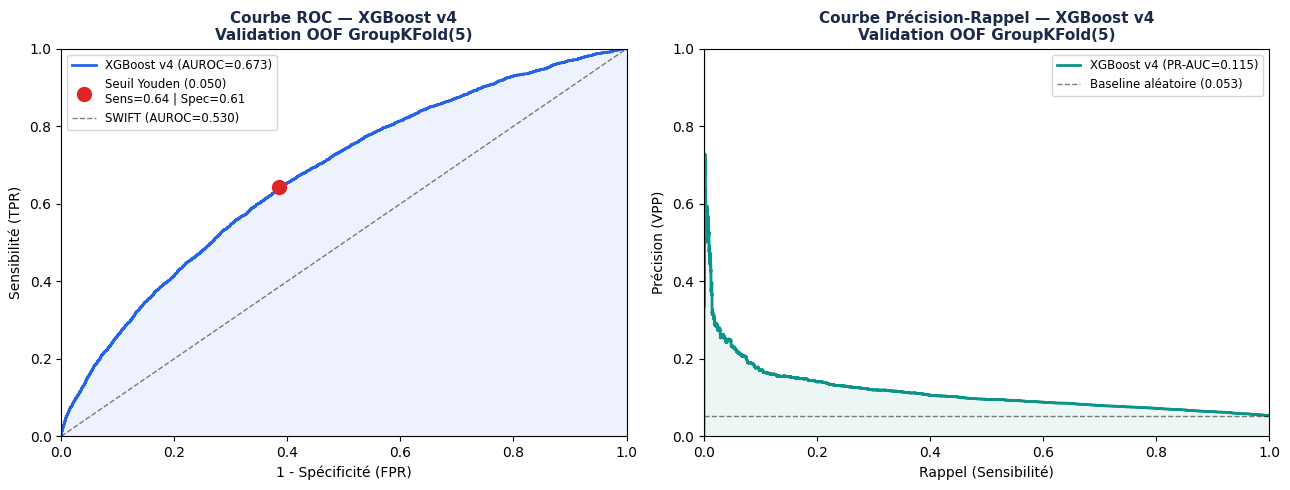

✓ Courbes ROC + PR sauvegardées


In [24]:
# ============================================================
# MÉTRIQUES COMPLÈTES — XGBoost v4 (modèle final)
# ============================================================
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
import numpy as np

y_true = y.values
y_prob = oof_proba4

# ── Seuil optimal — critère de Youden ────────────────────
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred = (y_prob >= best_threshold).astype(int)

# ── Matrice de confusion ──────────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp)   # Precision / VPP
npv         = tn / (tn + fn)   # VPN
f1          = 2 * tp / (2*tp + fp + fn)
accuracy    = (tp + tn) / len(y_true)

# ── Affichage ─────────────────────────────────────────────
print("="*55)
print("  MÉTRIQUES COMPLÈTES — XGBoost v4 (OOF 5 folds)")
print("="*55)

print(f"\n  Seuil optimal (Youden) : {best_threshold:.4f}")
print(f"  Prévalence réelle      : {y_true.mean()*100:.1f}%")

print(f"\n── Métriques de discrimination ──")
print(f"  AUROC                  : {roc_auc_score(y_true, y_prob):.4f}")
print(f"  PR-AUC                 : {average_precision_score(y_true, y_prob):.4f}")

print(f"\n── Calibration ──────────────────")
print(f"  Brier Score            : {brier_score_loss(y_true, y_prob):.4f}")
print(f"  Mean proba prédit      : {y_prob.mean():.4f}  (attendu ~{y_true.mean():.4f})")

print(f"\n── Au seuil Youden ({best_threshold:.3f}) ──────────")
print(f"  Sensibilité (Rappel)   : {sensitivity:.4f}  ({sensitivity*100:.1f}%)")
print(f"  Spécificité            : {specificity:.4f}  ({specificity*100:.1f}%)")
print(f"  VPP (Précision)        : {ppv:.4f}  ({ppv*100:.1f}%)")
print(f"  VPN                    : {npv:.4f}  ({npv*100:.1f}%)")
print(f"  F1 Score               : {f1:.4f}")
print(f"  Accuracy               : {accuracy:.4f}  ({accuracy*100:.1f}%)")

print(f"\n── Matrice de confusion ─────────")
print(f"              Prédit -    Prédit +")
print(f"  Réel -   :  TN={tn:>6,}   FP={fp:>5,}")
print(f"  Réel +   :  FN={fn:>6,}   TP={tp:>5,}")

print(f"\n── Interprétation clinique ──────")
print(f"  Sur {len(y_true):,} patients :")
print(f"  → {tp:,} réadmissions correctement identifiées")
print(f"  → {fn:,} réadmissions manquées (faux négatifs)")
print(f"  → {fp:,} alarmes inutiles (faux positifs)")
print(f"  → {tn:,} sorties correctement validées")

print(f"\n── Comparaison littérature ──────")
print(f"  SWIFT AUROC            : 0.530")
print(f"  Notre AUROC            : {roc_auc_score(y_true, y_prob):.4f}  (+{roc_auc_score(y_true, y_prob)-0.530:.4f})")
print(f"  Neves 2024 (MIMIC-IV)  : 0.68–0.70")
print(f"  Shi 2022 (ext. MIMIC)  : 0.60")

# ── Courbe ROC + PR ───────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

NAVY = '#1B2A4A'
BLUE = '#2563EB'
TEAL = '#0D9488'
RED  = '#DC2626'
GRAY = '#9CA3AF'

# ROC
axes[0].plot(fpr, tpr, color=BLUE, lw=2,
             label=f'XGBoost v4 (AUROC={roc_auc_score(y_true, y_prob):.3f})')
axes[0].scatter(fpr[youden_idx], tpr[youden_idx],
                color=RED, s=100, zorder=5,
                label=f'Seuil Youden ({best_threshold:.3f})\n'
                      f'Sens={sensitivity:.2f} | Spec={specificity:.2f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5,
             label=f'SWIFT (AUROC=0.530)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color=BLUE)
axes[0].set_xlabel('1 - Spécificité (FPR)', fontsize=10)
axes[0].set_ylabel('Sensibilité (TPR)', fontsize=10)
axes[0].set_title('Courbe ROC — XGBoost v4\nValidation OOF GroupKFold(5)',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[0].legend(fontsize=8.5)
axes[0].set_xlim(0,1)
axes[0].set_ylim(0,1)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_true, y_prob)
baseline_pr = y_true.mean()
axes[1].plot(recall, precision, color=TEAL, lw=2,
             label=f'XGBoost v4 (PR-AUC={average_precision_score(y_true, y_prob):.3f})')
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', lw=1, alpha=0.5,
                label=f'Baseline aléatoire ({baseline_pr:.3f})')
axes[1].fill_between(recall, precision, alpha=0.08, color=TEAL)
axes[1].set_xlabel('Rappel (Sensibilité)', fontsize=10)
axes[1].set_ylabel('Précision (VPP)', fontsize=10)
axes[1].set_title('Courbe Précision-Rappel — XGBoost v4\nValidation OOF GroupKFold(5)',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[1].legend(fontsize=8.5)
axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)

plt.tight_layout()
plt.savefig('../figures/fig_roc_pr_curves.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Courbes ROC + PR sauvegardées")